# Análisis del entorno y establecimiento del baseline

En este notebook se analiza el entorno ALE/SpaceInvaders-v5 y se establece un punto de referencia antes de entrenar los agentes de aprendizaje por refuerzo.

Se evaluarán dos agentes que no requieren entrenamiento:

1. **Agente aleatorio:** selecciona acciones al azar y representa el desempeño sin aprendizaje ni conocimiento del entorno.
2. **Agente basado en reglas:** se desplaza de un lado a otro mientras dispara constantemente e incorpora conocimiento básico del juego.

Los resultados de estos agentes servirán como referencia para determinar si los modelos entrenados posteriormente, como DQN, Double DQN y Dueling DQN, aprendieron políticas realmente útiles.

Para comparar los agentes se registrarán:

- Recompensa acumulada por episodio.
- Duración de cada episodio.
- Recompensa promedio y mediana.
- Desviación estándar.
- Recompensa mínima y máxima.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")

from ale_utils import (
    crear_entorno,
    correr_episodios,
    agente_aleatorio,
    AgenteReglaSimple,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Configuración del experimento
NOMBRE_ENTORNO = "ALE/SpaceInvaders-v5"
N_EPISODIOS = 30
SEMILLA_BASE = 42

print(f"Entorno seleccionado: {NOMBRE_ENTORNO}")
print(f"Número de episodios por agente: {N_EPISODIOS}")
print(f"Semilla base: {SEMILLA_BASE}")

Entorno seleccionado: ALE/SpaceInvaders-v5
Número de episodios por agente: 30
Semilla base: 42


## Entrono sin preprocesamiento

In [6]:
env_original = crear_entorno(
    nombre_entorno=NOMBRE_ENTORNO,
    aplicar_preprocesamiento=False,
    full_action_space=False,
)

observacion, info = env_original.reset(seed=SEMILLA_BASE)
env_original.action_space.seed(SEMILLA_BASE)

significados_acciones = env_original.unwrapped.get_action_meanings()

print("ESPACIO DE OBSERVACIÓN")
print(f"Forma de la observación: {observacion.shape}")
print(f"Tipo de datos: {observacion.dtype}")
print(f"Valor mínimo: {observacion.min()}")
print(f"Valor máximo: {observacion.max()}")
print(f"Espacio declarado: {env_original.observation_space}")

print("\nESPACIO DE ACCIONES")
print(f"Número de acciones: {env_original.action_space.n}")

for indice, significado in enumerate(significados_acciones):
    print(f"Acción {indice}: {significado}")

print("\nINFORMACIÓN INICIAL")
print(info)

env_original.close()

ESPACIO DE OBSERVACIÓN
Forma de la observación: (210, 160, 3)
Tipo de datos: uint8
Valor mínimo: 0
Valor máximo: 181
Espacio declarado: Box(0, 255, (210, 160, 3), uint8)

ESPACIO DE ACCIONES
Número de acciones: 6
Acción 0: NOOP
Acción 1: FIRE
Acción 2: RIGHT
Acción 3: LEFT
Acción 4: RIGHTFIRE
Acción 5: LEFTFIRE

INFORMACIÓN INICIAL
{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0, 'seeds': (np.uint32(3444837047), np.uint32(2669555309))}


## Análisis del espacio de observación y acciones

El entorno original entrega una observación con dimensiones (210, 160, 3). Esto corresponde a una imagen RGB de 210 píxeles de alto, 160 píxeles de ancho y tres canales de color. Los píxeles se representan mediante valores enteros sin signo de 8 bits (uint8) y el espacio permite valores entre 0 y 255.

En la observación inicial examinada, los valores se encontraron entre 0 y 181. Sin embargo, este rango corresponde únicamente al frame observado y no modifica el rango general de 0 a 255 declarado por el entorno.

Se utilizará el conjunto mínimo de seis acciones porque contiene todos los movimientos necesarios para jugar Space Invaders. Evitar las acciones redundantes reduce el espacio de búsqueda y puede facilitar el aprendizaje.

La información inicial indica que el agente comienza con **tres vidas**. Durante la evaluación, un episodio debe representar la partida completa y solamente finalizar cuando se agoten estas vidas o el entorno alcance otra condición de terminación.

## Inspecicón del preprocesamiento

In [7]:
env_preprocesado = crear_entorno(
    nombre_entorno=NOMBRE_ENTORNO,
    aplicar_preprocesamiento=True,
    frame_skip=4,
    screen_size=84,
    grayscale=True,
    stack_size=4,
    terminal_on_life_loss=False,
    clip_reward=False,
    noop_max=30,
    full_action_space=False,
)

observacion, info = env_preprocesado.reset(seed=SEMILLA_BASE)

print("OBSERVACIÓN PREPROCESADA")
print(f"Forma: {observacion.shape}")
print(f"Tipo de datos: {observacion.dtype}")
print(f"Valor mínimo: {np.asarray(observacion).min()}")
print(f"Valor máximo: {np.asarray(observacion).max()}")
print(f"Espacio declarado: {env_preprocesado.observation_space}")

print("\nCONFIGURACIÓN UTILIZADA")
print("Escala de grises: Sí")
print("Tamaño de cada frame: 84 × 84")
print("Frames apilados: 4")
print("Frame skip: 4")
print("Finalizar al perder una vida: No")
print("Clipping de recompensa: No")
print("No-ops aleatorios iniciales: entre 0 y 30")

env_preprocesado.close()

OBSERVACIÓN PREPROCESADA
Forma: (4, 84, 84)
Tipo de datos: uint8
Valor mínimo: 0
Valor máximo: 133
Espacio declarado: Box(0, 255, (4, 84, 84), uint8)

CONFIGURACIÓN UTILIZADA
Escala de grises: Sí
Tamaño de cada frame: 84 × 84
Frames apilados: 4
Frame skip: 4
Finalizar al perder una vida: No
Clipping de recompensa: No
No-ops aleatorios iniciales: entre 0 y 30


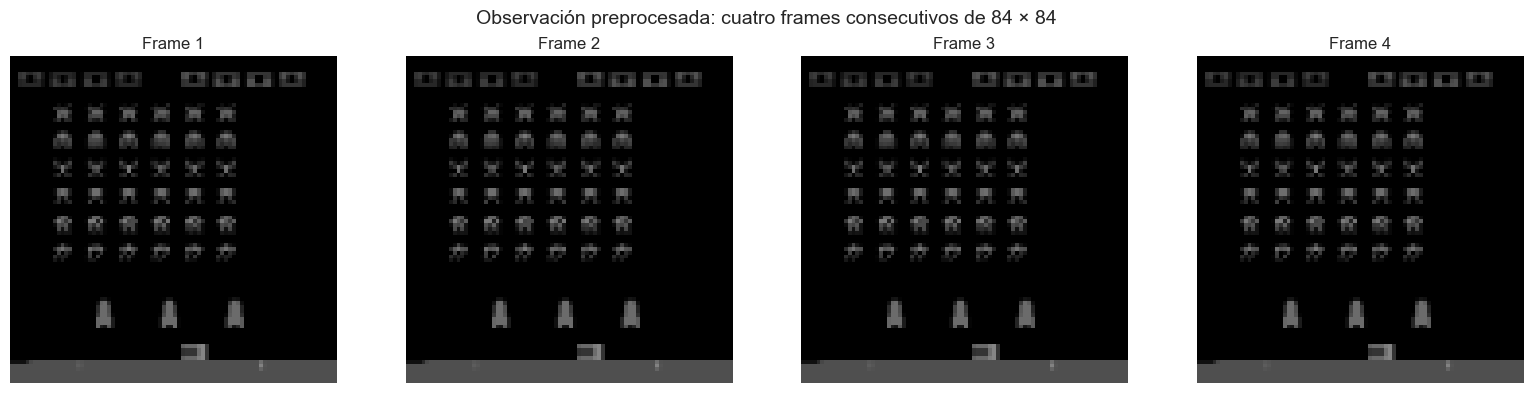

In [8]:
frames = np.asarray(observacion)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for indice, ax in enumerate(axes):
    ax.imshow(
        frames[indice],
        cmap="gray",
        vmin=0,
        vmax=255,
    )
    ax.set_title(f"Frame {indice + 1}")
    ax.axis("off")

fig.suptitle(
    "Observación preprocesada: cuatro frames consecutivos de 84 × 84",
    fontsize=14,
)

plt.tight_layout()
plt.show()

## Baseline

In [9]:
import importlib
import ale_utils

importlib.reload(ale_utils)

from ale_utils import (
    crear_entorno,
    correr_episodios,
    agente_aleatorio,
    AgenteReglaSimple,
)

configuracion_evaluacion = {
    "aplicar_preprocesamiento": True,
    "frame_skip": 4,
    "screen_size": 84,
    "grayscale": True,
    "stack_size": 4,
    "terminal_on_life_loss": False,
    "clip_reward": False,
    "noop_max": 30,
    "full_action_space": False,
}

print("Primera ejecución")
prueba_1 = correr_episodios(
    nombre_entorno=NOMBRE_ENTORNO,
    funcion_agente=agente_aleatorio,
    n_episodios=3,
    seed_base=SEMILLA_BASE,
    **configuracion_evaluacion,
)

print("\nSegunda ejecución con las mismas semillas")
prueba_2 = correr_episodios(
    nombre_entorno=NOMBRE_ENTORNO,
    funcion_agente=agente_aleatorio,
    n_episodios=3,
    seed_base=SEMILLA_BASE,
    **configuracion_evaluacion,
)

recompensas_1 = [resultado["recompensa_total"] for resultado in prueba_1]
recompensas_2 = [resultado["recompensa_total"] for resultado in prueba_2]

pasos_1 = [resultado["pasos"] for resultado in prueba_1]
pasos_2 = [resultado["pasos"] for resultado in prueba_2]

print("\nResultados de la comprobación")
print(f"Recompensas de la primera ejecución: {recompensas_1}")
print(f"Recompensas de la segunda ejecución: {recompensas_2}")
print(f"¿Las recompensas coinciden?: {recompensas_1 == recompensas_2}")
print(f"¿Las duraciones coinciden?: {pasos_1 == pasos_2}")

Primera ejecución
3 episodios | promedio=221.67 | std=59.49 | max=290.00 | min=145.00

Segunda ejecución con las mismas semillas
3 episodios | promedio=221.67 | std=59.49 | max=290.00 | min=145.00

Resultados de la comprobación
Recompensas de la primera ejecución: [290.0, 230.0, 145.0]
Recompensas de la segunda ejecución: [290.0, 230.0, 145.0]
¿Las recompensas coinciden?: True
¿Las duraciones coinciden?: True


## Reproducibilidad del baseline

Para obtener una comparación justa y reproducible, cada episodio se ejecuta utilizando una semilla controlada. Se realizaron dos ejecuciones del agente aleatorio utilizando las mismas tres semillas. Ambas produjeron las mismas recompensas y coincidieron en la duración de cada episodio. Esto confirma que la inicialización del entorno y el muestreo de acciones aleatorias pueden reproducirse.

Todos los agentes del baseline se evaluarán con el mismo conjunto de semillas. Posteriormente, los modelos entrenados también utilizarán estas semillas durante su evaluación, permitiendo comparar sus resultados bajo condiciones iniciales equivalentes.

La semilla se utiliza únicamente para hacer reproducible el experimento. No elimina la variabilidad entre episodios, ya que cada episodio recibe una semilla distinta.

## Agente aleatorio

In [10]:
print(f"Evaluando agente aleatorio durante {N_EPISODIOS} episodios...\n")

resultados_aleatorio = correr_episodios(
    nombre_entorno=NOMBRE_ENTORNO,
    funcion_agente=agente_aleatorio,
    n_episodios=N_EPISODIOS,
    seed_base=SEMILLA_BASE,
    **configuracion_evaluacion,
)

df_aleatorio = pd.DataFrame(resultados_aleatorio)

df_aleatorio["agente"] = "Aleatorio"

df_aleatorio = df_aleatorio[
    [
        "agente",
        "episodio",
        "seed",
        "recompensa_total",
        "pasos",
        "terminated",
        "truncated",
    ]
]

display(df_aleatorio.head(10))

Evaluando agente aleatorio durante 30 episodios...

30 episodios | promedio=165.67 | std=97.59 | max=485.00 | min=35.00


,agente,episodio,seed,recompensa_total,pasos,terminated,truncated
0,Aleatorio,0,42,290.0,758,True,False
1,Aleatorio,1,43,230.0,645,True,False
2,Aleatorio,2,44,145.0,546,True,False
3,Aleatorio,3,45,165.0,583,True,False
4,Aleatorio,4,46,65.0,454,True,False
5,Aleatorio,5,47,80.0,408,True,False
6,Aleatorio,6,48,110.0,468,True,False
7,Aleatorio,7,49,150.0,534,True,False
8,Aleatorio,8,50,95.0,499,True,False
9,Aleatorio,9,51,230.0,619,True,False


## Agente con regla simple

In [11]:
agente_regla = AgenteReglaSimple(pasos_por_tramo=25)

print(f"Evaluando agente por reglas durante {N_EPISODIOS} episodios...\n")

resultados_regla = correr_episodios(
    nombre_entorno=NOMBRE_ENTORNO,
    funcion_agente=agente_regla,
    n_episodios=N_EPISODIOS,
    seed_base=SEMILLA_BASE,
    **configuracion_evaluacion,
)

df_regla = pd.DataFrame(resultados_regla)

df_regla["agente"] = "Regla simple"

df_regla = df_regla[
    [
        "agente",
        "episodio",
        "seed",
        "recompensa_total",
        "pasos",
        "terminated",
        "truncated",
    ]
]

display(df_regla.head(10))

Evaluando agente por reglas durante 30 episodios...

30 episodios | promedio=211.50 | std=93.88 | max=360.00 | min=55.00


,agente,episodio,seed,recompensa_total,pasos,terminated,truncated
0,Regla simple,0,42,240.0,726,True,False
1,Regla simple,1,43,310.0,723,True,False
2,Regla simple,2,44,190.0,463,True,False
3,Regla simple,3,45,165.0,569,True,False
4,Regla simple,4,46,180.0,570,True,False
5,Regla simple,5,47,265.0,689,True,False
6,Regla simple,6,48,230.0,638,True,False
7,Regla simple,7,49,165.0,484,True,False
8,Regla simple,8,50,65.0,443,True,False
9,Regla simple,9,51,165.0,443,True,False


## Tabla comparativa de métricas

In [12]:
df_baseline = pd.concat(
    [df_aleatorio, df_regla],
    ignore_index=True,
)

resumen_baseline = (
    df_baseline
    .groupby("agente")
    .agg(
        episodios=("recompensa_total", "count"),
        promedio=("recompensa_total", "mean"),
        mediana=("recompensa_total", "median"),
        desviacion_estandar=("recompensa_total", "std"),
        minimo=("recompensa_total", "min"),
        maximo=("recompensa_total", "max"),
        pasos_promedio=("pasos", "mean"),
        episodios_terminados=("terminated", "sum"),
        episodios_truncados=("truncated", "sum"),
    )
    .reset_index()
)

columnas_decimales = [
    "promedio",
    "mediana",
    "desviacion_estandar",
    "pasos_promedio",
]

resumen_baseline[columnas_decimales] = (
    resumen_baseline[columnas_decimales].round(2)
)

display(resumen_baseline)

,agente,episodios,promedio,mediana,desviacion_estandar,minimo,maximo,pasos_promedio,episodios_terminados,episodios_truncados
0,Aleatorio,30,165.67,137.5,99.26,35.0,485.0,524.03,30,0
1,Regla simple,30,211.50,190.0,95.49,55.0,360.0,569.33,30,0


## Comparación con las mismas semillas

In [13]:
comparacion_pareada = df_baseline.pivot(
    index="seed",
    columns="agente",
    values="recompensa_total",
).reset_index()

# Diferencia positiva: la regla simple obtuvo mayor recompensa
comparacion_pareada["diferencia"] = (
    comparacion_pareada["Regla simple"]
    - comparacion_pareada["Aleatorio"]
)

victorias_regla = (comparacion_pareada["diferencia"] > 0).sum()
empates = (comparacion_pareada["diferencia"] == 0).sum()
victorias_aleatorio = (comparacion_pareada["diferencia"] < 0).sum()

mejora_promedio = comparacion_pareada["diferencia"].mean()

mejora_porcentual = (
    (
        resumen_baseline.loc[
            resumen_baseline["agente"] == "Regla simple",
            "promedio",
        ].iloc[0]
        /
        resumen_baseline.loc[
            resumen_baseline["agente"] == "Aleatorio",
            "promedio",
        ].iloc[0]
    )
    - 1
) * 100

print("COMPARACIÓN PAREADA")
print(f"Victorias de la regla simple: {victorias_regla}")
print(f"Victorias del agente aleatorio: {victorias_aleatorio}")
print(f"Empates: {empates}")
print(f"Diferencia promedio: {mejora_promedio:.2f} puntos")
print(f"Mejora porcentual del promedio: {mejora_porcentual:.2f}%")

display(comparacion_pareada.head(10))

COMPARACIÓN PAREADA
Victorias de la regla simple: 17
Victorias del agente aleatorio: 12
Empates: 1
Diferencia promedio: 45.83 puntos
Mejora porcentual del promedio: 27.66%


agente,seed,Aleatorio,Regla simple,diferencia
0,42,290.0,240.0,-50.0
1,43,230.0,310.0,80.0
2,44,145.0,190.0,45.0
3,45,165.0,165.0,0.0
4,46,65.0,180.0,115.0
5,47,80.0,265.0,185.0
6,48,110.0,230.0,120.0
7,49,150.0,165.0,15.0
8,50,95.0,65.0,-30.0
9,51,230.0,165.0,-65.0


## Interpretación de los resultados del baseline

El agente aleatorio obtuvo una recompensa promedio de **165.67 puntos**, mientras que el agente basado en reglas alcanzó un promedio de **211.50 puntos**. La incorporación de una estrategia sencilla produjo una mejora promedio de **45.83 puntos**, equivalente a aproximadamente **27.66 %** respecto al agente aleatorio.

La mediana también aumentó de **137.5** a **190 puntos**, lo que indica que la mejora no depende de unos pocos episodios excepcionales. Además, el agente por reglas permaneció activo durante más tiempo: alcanzó un promedio de **569.33 pasos**, frente a **524.03 pasos** del agente aleatorio.

Al comparar ambos agentes con las mismas 30 semillas, la regla simple obtuvo una recompensa mayor en 17 episodios, el agente aleatorio ganó en 12 y se produjo un empate. Por lo tanto, la regla simple presenta un mejor rendimiento general, pero no supera al agente aleatorio en todas las condiciones iniciales.

El agente aleatorio obtuvo el máximo individual más alto, con **485 puntos**, frente a los **360 puntos** de la regla simple. El episodio máximo puede estar influido por variabilidad y resultados afortunados, por lo que no debe utilizarse como el único criterio de selección.

A partir de estos resultados se establecen dos referencias:

- Un agente entrenado debe superar claramente los **165.67 puntos** del agente aleatorio.
- Para demostrar que aprendió una política más útil que una estrategia manual sencilla, debería superar de forma consistente los **211.50 puntos** de la regla simple.

Los modelos entrenados serán evaluados con múltiples episodios y las mismas semillas. Se considerarán principalmente la recompensa promedio y la mediana, además del máximo obtenido para representar el criterio utilizado durante la competencia.

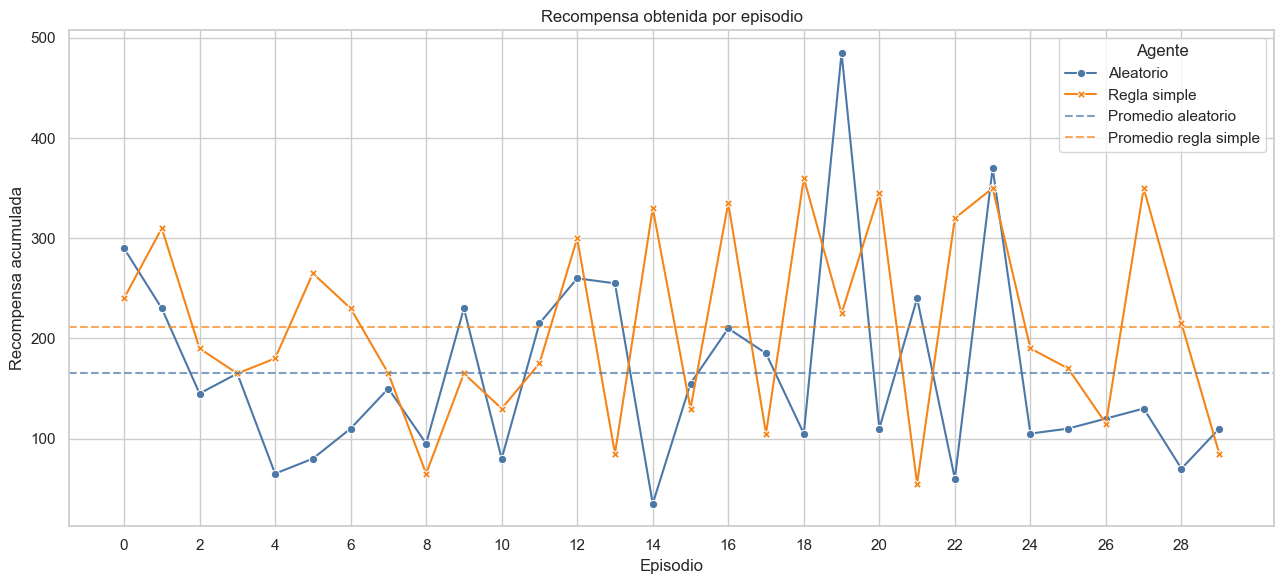

In [14]:
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=df_baseline,
    x="episodio",
    y="recompensa_total",
    hue="agente",
    style="agente",
    markers=True,
    dashes=False,
    palette={
        "Aleatorio": "#4C78A8",
        "Regla simple": "#F58518",
    },
)

plt.axhline(
    y=df_aleatorio["recompensa_total"].mean(),
    color="#4C78A8",
    linestyle="--",
    alpha=0.7,
    label="Promedio aleatorio",
)

plt.axhline(
    y=df_regla["recompensa_total"].mean(),
    color="#F58518",
    linestyle="--",
    alpha=0.7,
    label="Promedio regla simple",
)

plt.title("Recompensa obtenida por episodio")
plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")
plt.xticks(range(0, N_EPISODIOS, 2))
plt.legend(title="Agente")
plt.tight_layout()
plt.show()

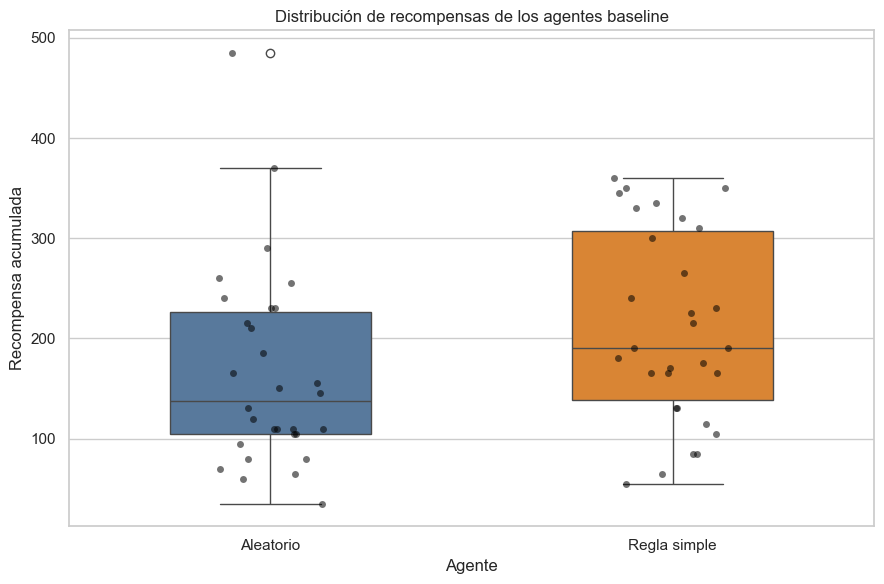

In [15]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_baseline,
    x="agente",
    y="recompensa_total",
    hue="agente",
    palette={
        "Aleatorio": "#4C78A8",
        "Regla simple": "#F58518",
    },
    legend=False,
    width=0.5,
)

sns.stripplot(
    data=df_baseline,
    x="agente",
    y="recompensa_total",
    color="black",
    alpha=0.55,
    jitter=0.15,
    size=5,
)

plt.title("Distribución de recompensas de los agentes baseline")
plt.xlabel("Agente")
plt.ylabel("Recompensa acumulada")
plt.tight_layout()
plt.show()

In [16]:
df_baseline["bloque_de_5"] = (df_baseline["episodio"] // 5) + 1

mejores_de_5 = (
    df_baseline
    .groupby(["agente", "bloque_de_5"], as_index=False)
    .agg(
        mejor_recompensa=("recompensa_total", "max"),
        promedio_del_bloque=("recompensa_total", "mean"),
    )
)

mejores_de_5["promedio_del_bloque"] = (
    mejores_de_5["promedio_del_bloque"].round(2)
)

print("RESULTADOS DE SEIS SIMULACIONES DE COMPETENCIA")
display(mejores_de_5)

resumen_mejor_de_5 = (
    mejores_de_5
    .groupby("agente")
    .agg(
        mejor_de_5_promedio=("mejor_recompensa", "mean"),
        menor_mejor_de_5=("mejor_recompensa", "min"),
        mayor_mejor_de_5=("mejor_recompensa", "max"),
    )
    .round(2)
    .reset_index()
)

print("\nRESUMEN DEL CRITERIO MEJOR DE CINCO")
display(resumen_mejor_de_5)

RESULTADOS DE SEIS SIMULACIONES DE COMPETENCIA


,agente,bloque_de_5,mejor_recompensa,promedio_del_bloque
0,Aleatorio,1,290.0,179.0
1,Aleatorio,2,230.0,133.0
2,Aleatorio,3,260.0,169.0
3,Aleatorio,4,485.0,228.0
4,Aleatorio,5,370.0,177.0
5,Aleatorio,6,130.0,108.0
6,Regla simple,1,310.0,217.0
7,Regla simple,2,265.0,178.0
8,Regla simple,3,330.0,204.0
9,Regla simple,4,360.0,231.0



RESUMEN DEL CRITERIO MEJOR DE CINCO


,agente,mejor_de_5_promedio,menor_mejor_de_5,mayor_mejor_de_5
0,Aleatorio,294.17,130.0,485.0
1,Regla simple,327.50,265.0,360.0


## Guardar resultados

In [17]:
carpeta_logs = Path("../logs")
carpeta_logs.mkdir(parents=True, exist_ok=True)

df_baseline.to_csv(
    carpeta_logs / "baseline_episodios.csv",
    index=False,
)

resumen_baseline.to_csv(
    carpeta_logs / "baseline_resumen.csv",
    index=False,
)

mejores_de_5.to_csv(
    carpeta_logs / "baseline_mejores_de_5.csv",
    index=False,
)

print("Archivos guardados correctamente:")
print(f"- {carpeta_logs / 'baseline_episodios.csv'}")
print(f"- {carpeta_logs / 'baseline_resumen.csv'}")
print(f"- {carpeta_logs / 'baseline_mejores_de_5.csv'}")

Archivos guardados correctamente:
- ../logs/baseline_episodios.csv
- ../logs/baseline_resumen.csv
- ../logs/baseline_mejores_de_5.csv


## Conclusiones del baseline

La evaluación de 30 episodios permitió establecer puntos de referencia reproducibles para comparar los modelos de aprendizaje por refuerzo.

Bajo el criterio de competencia, en el que se toma el mejor resultado de cinco episodios, la regla simple obtuvo un valor promedio de **327.50 puntos**. Además, sus resultados fueron más consistentes, mientras que las del agente aleatorio estuvieron entre **130 y 485 puntos**.

A partir de estos resultados, se establecen los siguientes criterios de comparación:

- Un modelo entrenado debe superar claramente el promedio aleatorio de **165.67 puntos**.
- Para demostrar que aprendió una política útil, debe superar de forma consistente el promedio de **211.50 puntos** de la regla simple.
- Como referencia para la competencia, se buscará superar un mejor resultado de cinco cercano a **327.50 puntos**.
- La selección del modelo final no se realizará únicamente con el episodio máximo, sino considerando también el promedio, la mediana y la estabilidad entre episodios.

Estos resultados se utilizarán como referencia para evaluar las siguientes iteraciones: DQN vanilla, Double DQN y Dueling Double DQN.